<a href="https://colab.research.google.com/github/mathwadde/maching-learning-course-work/blob/main/PART_2_EXAM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
from google.colab import sheets
sh = sheets.InteractiveSheet()
df = sh.as_df()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_csv('ILORI Waheed data - raw data (1).csv')
df.head(10)

In [ ]:
df.columns

Index(['Deal ID', 'Closed Won Reason', 'Annual contract value',
       'Last Modified Date', 'Close Date', 'Deal Type', 'Expected Close Date',
       'Number of times contacted', 'Number of Sales Activities',
       'Original Source Type', 'Forecast Amount',
       'Medium of last booking in meetings tool', 'Create Date',
       'Date of last meeting booked in meetings tool', 'requestid',
       'Closed Lost Reason', 'Annual recurring revenue', 'referer',
       'Deal owner', 'Last Activity Date', 'Next Activity Date',
       'Source of last booking in meetings tool', 'Owner Assigned Date',
       'Deal Team', 'Deal Stage', 'Deal Owner 2', 'Number of Contacts',
       'Original Source Data 1', 'Total contract value', 'Deal Owner 3',
       'Last Contacted', 'HubSpot Team', 'Deal Name', 'Geographic Region',
       'Amount', 'Priority', 'Tags', 'Monthly recurring revenue',
       'Deal Description', 'Forecast category', 'Amount in company currency',
       'Create Date.1', 'Last Activity

In [ ]:
df = df[['Deal ID',
    #'Closed Won Reason', 'Annual contract value',
       #'Last Modified Date', 'Close Date', 'Deal Type', 'Expected Close Date',
       'Number of times contacted', 'Number of Sales Activities',
       'Original Source Type', 'Forecast Amount',
       #'Medium of last booking in meetings tool', 'Create Date',
       #'Date of last meeting booked in meetings tool', 'requestid',
       #'Closed Lost Reason', 'Annual recurring revenue', 'referer',
       'Deal owner',
         #'Last Activity Date',
    #'Next Activity Date',
      # 'Source of last booking in meetings tool', 'Owner Assigned Date',
       #'Deal Team', 'Deal Stage', 'Deal Owner 2', 'Number of Contacts',
       'Original Source Data 1',
       #Total contract value', 'Deal Owner 3',
       #'Last Contacted', #'HubSpot Team', 'Deal Name', #'Geographic Region',
       'Amount', #'Priority', 'Tags', 'Monthly recurring revenue',
       #'Deal Description', 'Forecast category',
         'Amount in company currency',
       'Create Date.1', 'Last Activity', 'Last contact', 'Closed Date']].copy()


In [ ]:
df.head(20)

,Deal ID,Number of times contacted,Number of Sales Activities,Original Source Type,Forecast Amount,Deal owner,Original Source Data 1,Amount,Amount in company currency,Create Date.1,Last Activity,Last contact,Closed Date
0,3974710472,40.0,55.0,Offline Sources,90000,Thomas Bohner,EXTENSION,90000,90000,2021-01-12 00:00,2021-06-25 00:00,6/25/21,2021-01-01 00:00
1,3355847518,42.0,70.0,Offline Sources,320000,Thomas Bohner,SALES,320000,320000,2020-11-09 00:00,2021-06-24 00:00,6/24/21,2020-11-02 00:00
2,3355855817,12.0,15.0,Offline Sources,67000,Thomas Bohner,CONTACTS,67000,67000,2020-11-09 00:00,2021-06-07 00:00,6/7/21,2020-08-04 00:00
3,3355889429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-09 00:00,NaN,NaN,2020-11-10 00:00
4,5501406833,10.0,13.0,Offline Sources,30000,Hanna Zubko,EXTENSION,30000,30000,2021-06-22 00:00,2021-06-22 00:00,6/22/21,2021-06-24 00:00
5,5119645529,5.0,5.0,Offline Sources,NaN,Chaim Finizola,EXTENSION,NaN,NaN,2021-04-28 00:00,2021-05-05 00:00,5/5/21,2021-04-30 00:00
6,3355898254,NaN,NaN,NaN,NaN,Chaim Finizola,NaN,NaN,NaN,2020-11-09 00:00,NaN,NaN,2020-11-12 00:00
7,3355862520,10.0,10.0,Offline Sources,"27136,49",Thomas Bohner,IMPORT,"27136,5","27136,49",2020-11-09 00:00,2021-03-02 00:00,3/2/21,2020-03-31 00:00
8,3521050909,32.0,46.0,Offline Sources,NaN,Robert van Donge,IMPORT,NaN,NaN,2020-11-25 00:00,2021-04-30 00:00,4/30/21,2020-11-30 00:00
9,3355865144,75.0,151.0,Offline Sources,2800000,Thomas Bohner,CONTACTS,2800000,2800000,2020-11-09 00:00,2021-06-29 00:00,6/28/21,2019-03-04 00:00


In [ ]:
df.columns


Index(['Deal ID', 'Number of times contacted', 'Number of Sales Activities',
       'Original Source Type', 'Forecast Amount', 'Deal owner',
       'Original Source Data 1', 'Amount', 'Amount in company currency',
       'Create Date.1', 'Last Activity', 'Last contact', 'Closed Date'],
      dtype='object')

In [ ]:
df =df[['Deal ID', 'Number of Sales Activities', 'Original Source Type',
       'Forecast Amount', 'Deal Stage', 'Deal Owner 2', 'Number of Contacts',
       'Original Source Data 1', 'Last Contacted','Geographic Region', 'Amount', 'Tags',
        'Deal Description',
       'Amount in company currency', 'Create Date.1', 'Last Activity',
       'Last contact', 'Closed Date']]

In [ ]:
df.shape

(305, 13)

In [ ]:
df.describe()

,Deal ID,Number of times contacted,Number of Sales Activities
count,3.050000e+02,154.000000,154.000000
mean,3.896435e+09,22.142857,34.110390
std,7.233804e+08,49.575245,68.175241
min,3.349256e+09,0.000000,0.000000
25%,3.355863e+09,2.000000,4.000000
50%,3.355902e+09,8.500000,13.000000
75%,4.227624e+09,26.500000,39.750000
max,5.526747e+09,527.000000,678.000000


In [ ]:
df.isna().sum()

,0
Deal ID,0
Number of times contacted,151
Number of Sales Activities,151
Original Source Type,111
Forecast Amount,223
Deal owner,40
Original Source Data 1,111
Amount,223
Amount in company currency,223
Create Date.1,0


In [ ]:
#df = df.loc[~df.duplicated(subset=['Deal Stage','Number of Contacts','Create Date.1' ]).reset_index(drop=True)].copy

In [ ]:
df.dtypes

,0
Deal ID,int64
Number of times contacted,float64
Number of Sales Activities,float64
Original Source Type,object
Forecast Amount,object
Deal owner,object
Original Source Data 1,object
Amount,object
Amount in company currency,object
Create Date.1,object


In [ ]:
df[['Amount', 'Amount in company currency']] = df[['Amount', 'Amount in company currency']].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.dtypes

,0
Deal ID,int64
Number of times contacted,float64
Number of Sales Activities,float64
Original Source Type,object
Forecast Amount,object
Deal owner,object
Original Source Data 1,object
Amount,float64
Amount in company currency,float64
Create Date.1,object


In [ ]:
df1=df[['Amount','Original Source Type']]

In [ ]:
df1 = df1.head(50).dropna()

In [ ]:
df1.head()

,Amount,Original Source Type
0,90000.0,Offline Sources
1,320000.0,Offline Sources
2,67000.0,Offline Sources
4,30000.0,Offline Sources
9,2800000.0,Offline Sources


In [ ]:
ax = df1.plot(kind='bar', x='Original Source Type', y='Amount', figsize=(10,6))
ax.xlabel('Original Source Type')
ax.ylabel('Amount')
ax.title('Amount by Original Source Type')

NameError: name 'df1' is not defined

<Axes: ylabel='Frequency'>

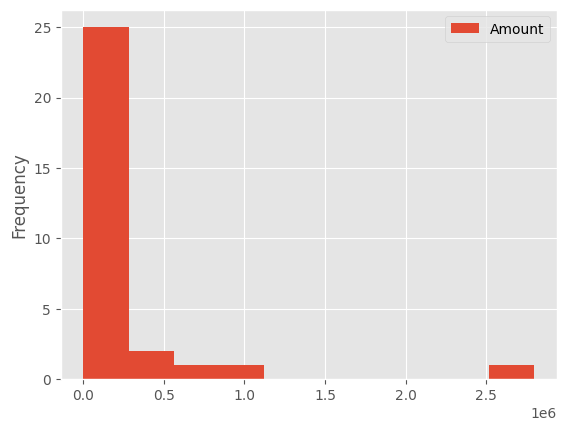

In [ ]:
df1.plot(kind='hist')

<Axes: >

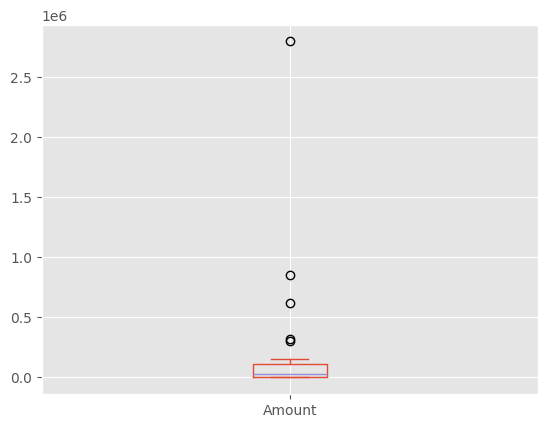

In [ ]:
df1.plot(kind='box')

In [ ]:
df2 = df[['Original Source Type','Amount in company currency']]

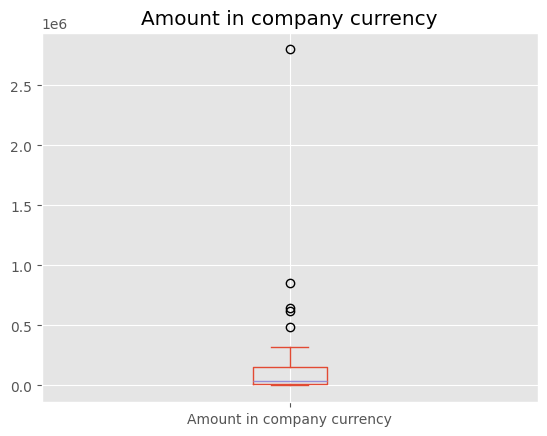

In [ ]:
ax = df2.plot(kind='box',title= 'Amount in company currency')


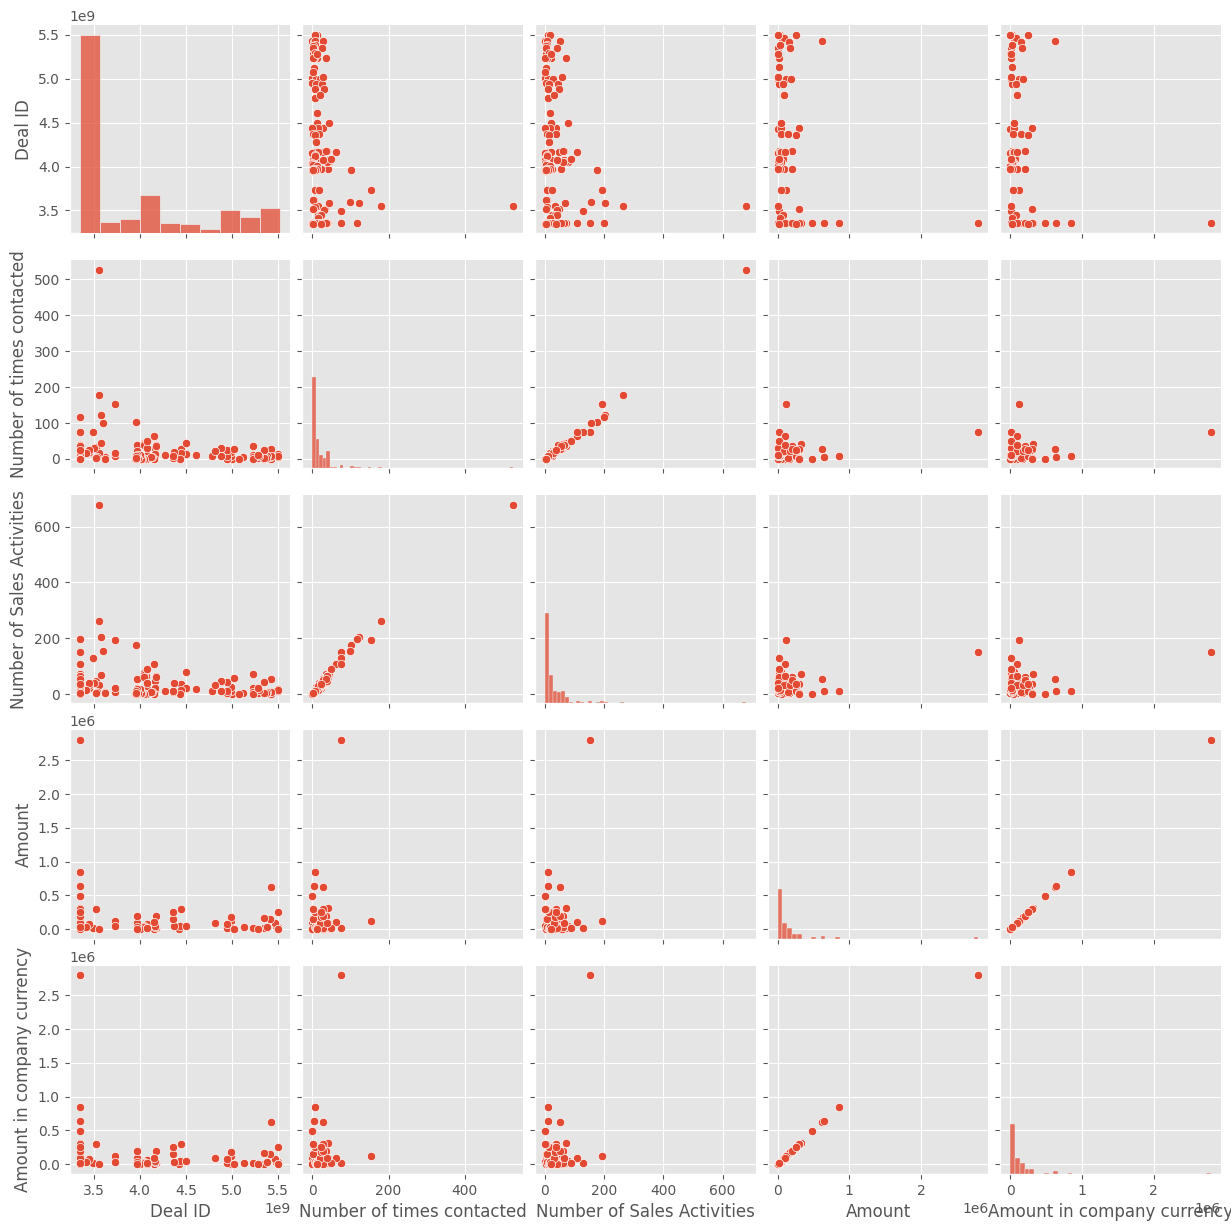

In [ ]:
sns.pairplot(df)

<Axes: xlabel='Amount', ylabel='Amount in company currency'>

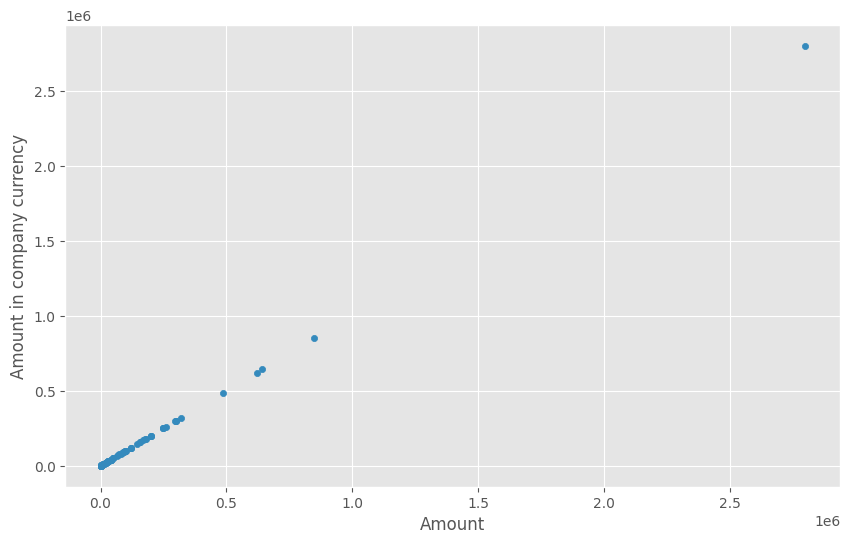

In [ ]:
df.plot(kind='scatter', x='Amount', y='Amount in company currency', figsize=(10,6))

<Axes: ylabel='Original Source Type'>

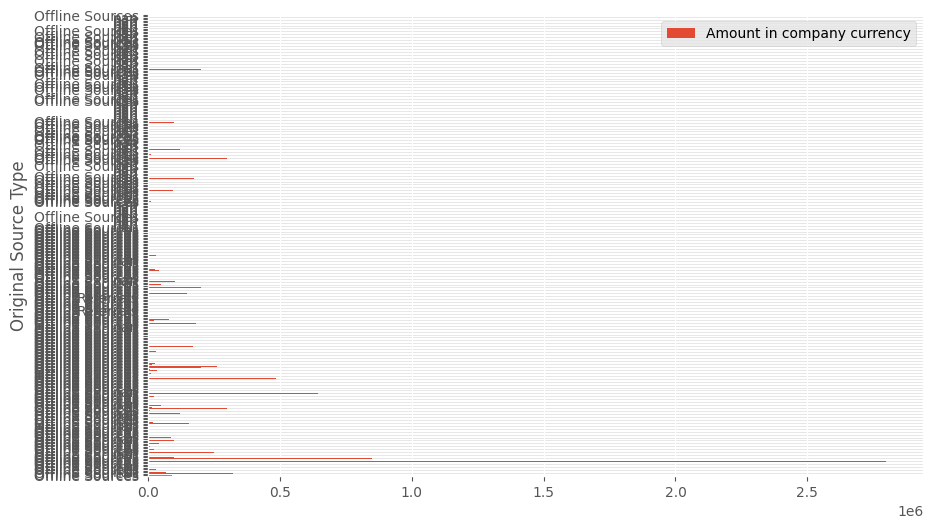

In [ ]:
df2.plot(kind='barh', x='Original Source Type', y='Amount in company currency', figsize=(10,6))

In [ ]:
df2= df2.sort_values(by='Amount in company currency', ascending=False).dropna()

<Axes: ylabel='Original Source Type'>

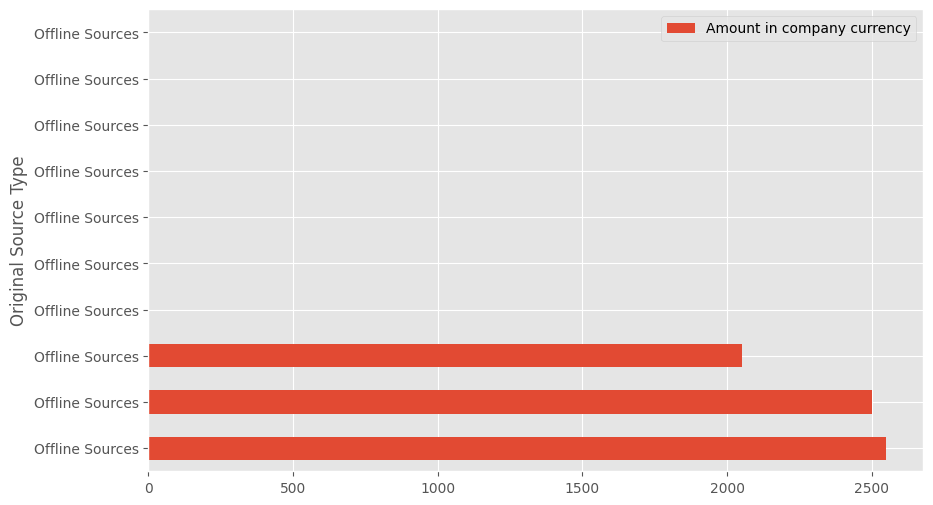

In [ ]:
df2.tail(10).plot(kind='barh', x='Original Source Type', y='Amount in company currency', figsize=(10,6))

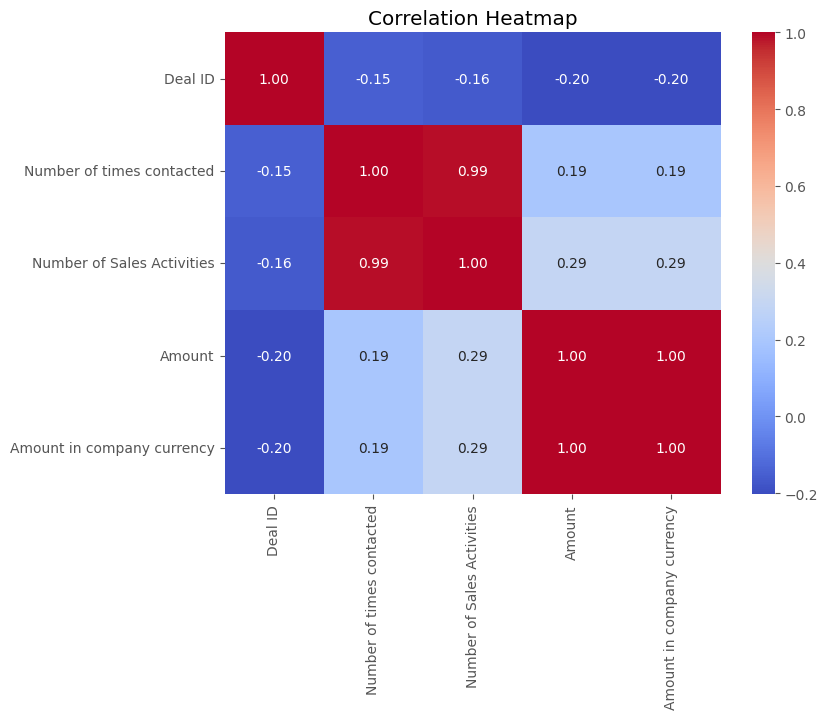

In [ ]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()